In [1]:
from subprocess import check_output

from aiida_vasp.utils.temp_profile import *

print(load_temp_profile())


# Uncomment the below line to create a localhost Computer if you have not done so
comp = orm.Computer('localhost', 'localhost', transport_type='core.local', scheduler_type='core.direct')
comp.store()


# Some configuration may be needed for first-time user
import os
from pathlib import Path

comp.set_workdir('/tmp/aiida_run/')
comp.configure()
vasp_path = check_output(['which', 'mock-vasp'], universal_newlines=True).strip()

vasp_code = orm.InstalledCode(comp, vasp_path, default_calc_job_plugin='vasp.vasp')
vasp_code.label = 'mock-vasp'
vasp_code.store()
os.environ['MOCK_VASP_REG_BASE'] = str((Path() / 'mock_registry').absolute())
os.environ['MOCK_VASP_UPLOAD_PREFIX'] = 'band'

# Upload the POTCAR files
from pathlib import Path

from aiida_vasp.data.potcar import PotcarData

print(PotcarData.upload_potcar_family(str(Path('potcars').absolute()), 'PBE.EXAMPLE', 'PBE.EXAMPLE'))

# Setting up the silicon structure
from ase.build import bulk

si = bulk('Si', 'diamond', 5.4)
si_node = orm.StructureData(ase=si)

Profile<uuid='9f322b4928e541b99a09cfae683c91ae' name='myprofile'>
(1, 1, 1)


In [2]:
from aiida_vasp.protocols.generator import VaspBandsInputGenerator
from aiida_vasp.workchains.v2.bands import BandOptions

upd = VaspBandsInputGenerator()
builder = upd.build(
    si_node,
    code='mock-vasp@localhost',
    run_relax=False,
    overrides={
        'scf': {'potential_family': 'PBE.EXAMPLE'},
    },
)

In [3]:
opt = BandOptions()
print(opt.aiida_description())
# Or by accessing the help with
?builder.band_settings

                              symprec:  float      
                                        Default: Precision of the symmetry determination
                            band_mode:  str        
                                        Default: Mode for generating the band path. Choose from: bradcrack, pymatgen,seekpath-aiida and latimer-munro.
                band_kpoints_distance:  float      
                                        Default: Spacing for band distances for automatic kpoints generation, used by seekpath-aiida mode.
                         line_density:  float      
                                        Default: Density of the point along the path, used by the sumo interface.
                 dos_kpoints_distance:  float      
                                        Default: Kpoints for running DOS calculations in A^-1 * 2pi. Will perform non-SCF DOS calculation is supplied.
                             only_dos:  bool       
                                        Defa

In [4]:
band_out = upd.run_get_node().node

04/01/2026 11:04:14 PM <808537> aiida.orm.nodes.process.workflow.workchain.WorkChainNode: [REPORT] [24|VaspNscfWorkChain|run_scf]: Correction: setting LCHARG to True


04/01/2026 11:04:14 PM <808537> aiida.orm.nodes.process.workflow.workchain.WorkChainNode: [REPORT] [24|VaspNscfWorkChain|run_scf]: Running SCF calculation uuid: 84d77ed1-f9bb-4825-948f-1108d96fb997 (pk: 27) (aiida.workflows:vasp.v2.vasp)


04/01/2026 11:04:15 PM <808537> aiida.orm.nodes.process.workflow.workchain.WorkChainNode: [REPORT] [27|VaspWorkChain|run_process]: launching VaspCalculation<32> iteration #1


04/01/2026 11:04:15 PM <808537> aiida.engine.processes.calcjobs.tasks: [WARNING] CalcJob<32> already marked as `CalcJobState.STASHING`, skipping task_monitor_job


04/01/2026 11:04:16 PM <808537> aiida.orm.nodes.process.workflow.workchain.WorkChainNode: [REPORT] [27|VaspWorkChain|results]: work chain completed after 1 iterations


...

04/01/2026 11:04:17 PM <808537> aiida.orm.nodes.process.workflow.workchain.WorkChainNode: [REPORT] [38|VaspWorkChain|run_process]: launching VaspCalculation<42> iteration #1


04/01/2026 11:04:17 PM <808537> aiida.orm.nodes.process.calculation.calcjob.CalcJobNode: [REPORT] [42|VaspCalculation|remote_copy_restart_folder]: WARNING: Object WAVECAR does not exist in the restart folder.


04/01/2026 11:04:18 PM <808537> aiida.engine.processes.calcjobs.tasks: [WARNING] CalcJob<42> already marked as `CalcJobState.STASHING`, skipping task_monitor_job


04/01/2026 11:04:18 PM <808537> aiida.orm.nodes.process.workflow.workchain.WorkChainNode: [REPORT] [38|VaspWorkChain|results]: work chain completed after 1 iterations


04/01/2026 11:04:18 PM <808537> aiida.orm.nodes.process.workflow.workchain.WorkChainNode: [REPORT] [38|VaspWorkChain|on_terminated]: cleaned remote folders of calculations: 42


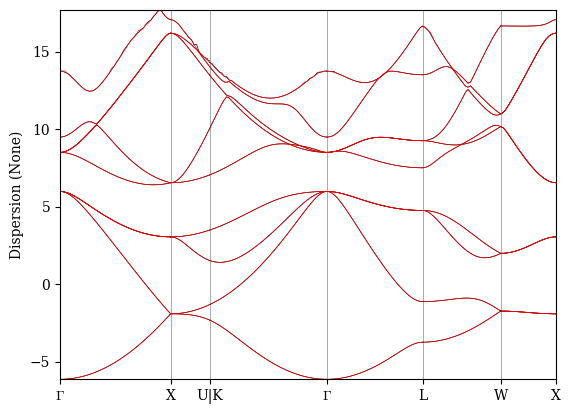

In [5]:
band_out.outputs.band_structure.show_mpl()